## Data Import and Filtering

In [2]:
# Standard libraries used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# --------------------------------------------------------------------------
# PARAMETER — PATH_DATASET
# --------------------------------------------------------------------------

PATH_DATASET = r"C:\Users\marco\Desktop\Tesi\.LabWork\Data\Data from Suzanne\fitness_calc_PB_H3B.xlsx"

# We load the raw file with no changes.
# data_raw will never be modified — it stays as the original reference.
data_raw = pd.read_excel(PATH_DATASET)


# --------------------------------------------------------------------------
# Data Filtering
# --------------------------------------------------------------------------

MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data_raw["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

data_filtered = data_raw[mask_ok].copy().reset_index(drop=True)

max_decoy_stratified = data_filtered[data_filtered['DECOY'] == 'Decoy 1']
no_decoy_stratified = data_filtered[data_filtered['DECOY'] == 'Decoy 7']

# --------------------------------------------------------------------------
# CONSTANT definition
# --------------------------------------------------------------------------
DRUG_CONCENTRATIONS = [1e-11, 1e-10, 2e-10, 4e-10, 1e-09]

## Function definition

In [3]:
def extract_bp(full_sequence, pyt_seq = 'UUUUUCUUUUCUUUU',
anchor_seq = 'GGGUUUCCUGAAGCUUUCG'):
    """

    Extracts the BP region from a full sequence located between 
    the anchor and the PYT sequence, removing the last 3 characters as 
    shown in the design 

    """
    # 1. Convert RNA inputs to DNA if necessary
    # (Using your logic: replace 'U' with 'T')
    def to_dna(s):
        return s.replace('U', 'T')

    anchor_dna = to_dna(anchor_seq)
    pyt_dna = to_dna(pyt_seq)

    # 2. Extract the raw string between anchor and PYT
    try:
        # Split by anchor and take the part after [1]
        # Then split by PYT and take the part before [0]
        raw_between = full_sequence.split(anchor_dna)[1].split(pyt_dna)[0]
        
        # 3. Apply your specific offset (removing the last 3 characters)
        bp_final = raw_between[:-3]
        return bp_final
    except IndexError:
        # Returns None or an empty string if the anchor/pyt are not found
        return None
    
def plot_fitness_vs_concentration(df1, df2=None, titles=None, save_path=None):
    """
    Generate a fitness-vs-concentration line plot.
    If df2 is provided, the two plots are shown side by side.

    Parameters
    ----------
    df1       : pd.DataFrame (required)
    df2       : pd.DataFrame (optional)
    titles    : list of 1 or 2 strings, e.g. ["Control", "Treated"]
    save_path : if given, saves the figure as that path (e.g. "fitness.png")

    Examples
    --------
    plot_fitness_vs_concentration(df1)
    plot_fitness_vs_concentration(df1, df2, titles=["Control", "Treated"])
    plot_fitness_vs_concentration(df1, df2, save_path="results/fitness.png")
    """

    columns_of_interest = ['fit_Ctrl', 'fit_PB1', 'fit_PB2', 'fit_PB4', 'fit_PB8']

    concentration_map = {
        'fit_Ctrl': 1e-11,
        'fit_PB1':  1e-10,
        'fit_PB2':  2e-10,
        'fit_PB4':  4e-10,
        'fit_PB8':  1e-9,
    }

    tick_positions = [1e-11, 1e-10, 2e-10, 4e-10, 1e-9]
    tick_labels    = ['$10^{-11}$', '$10^{-10}$', '$2\\times10^{-10}$', '$4\\times10^{-10}$', '$10^{-9}$']

    sns.set_theme(style="whitegrid")

    dataframes = [df1] if df2 is None else [df1, df2]
    n = len(dataframes)

    fig, axes = plt.subplots(1, n, figsize=(9 * n, 5))
    if n == 1:
        axes = [axes]  # make it iterable even with one plot

    for i, (df, ax) in enumerate(zip(dataframes, axes)):
        df_long = df[columns_of_interest].melt(var_name='Condition', value_name='Fitness')
        df_long['Concentration'] = df_long['Condition'].map(concentration_map)

        title = titles[i] if titles and i < len(titles) else f'DataFrame {i+1} - Fitness Variation'

        sns.lineplot(data=df_long, x='Concentration', y='Fitness',
                     marker='o', linewidth=2.5, color='#2c3e50', errorbar='ci', ax=ax)

        ax.set_xscale('log')
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel('PladB Concentration (M)', fontsize=12)
        ax.set_ylabel('Fitness Value', fontsize=12)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')

    plt.show()

# Max_Decoy VS No_Decoy -- Fitness Variation  -- Multivariate Analysis

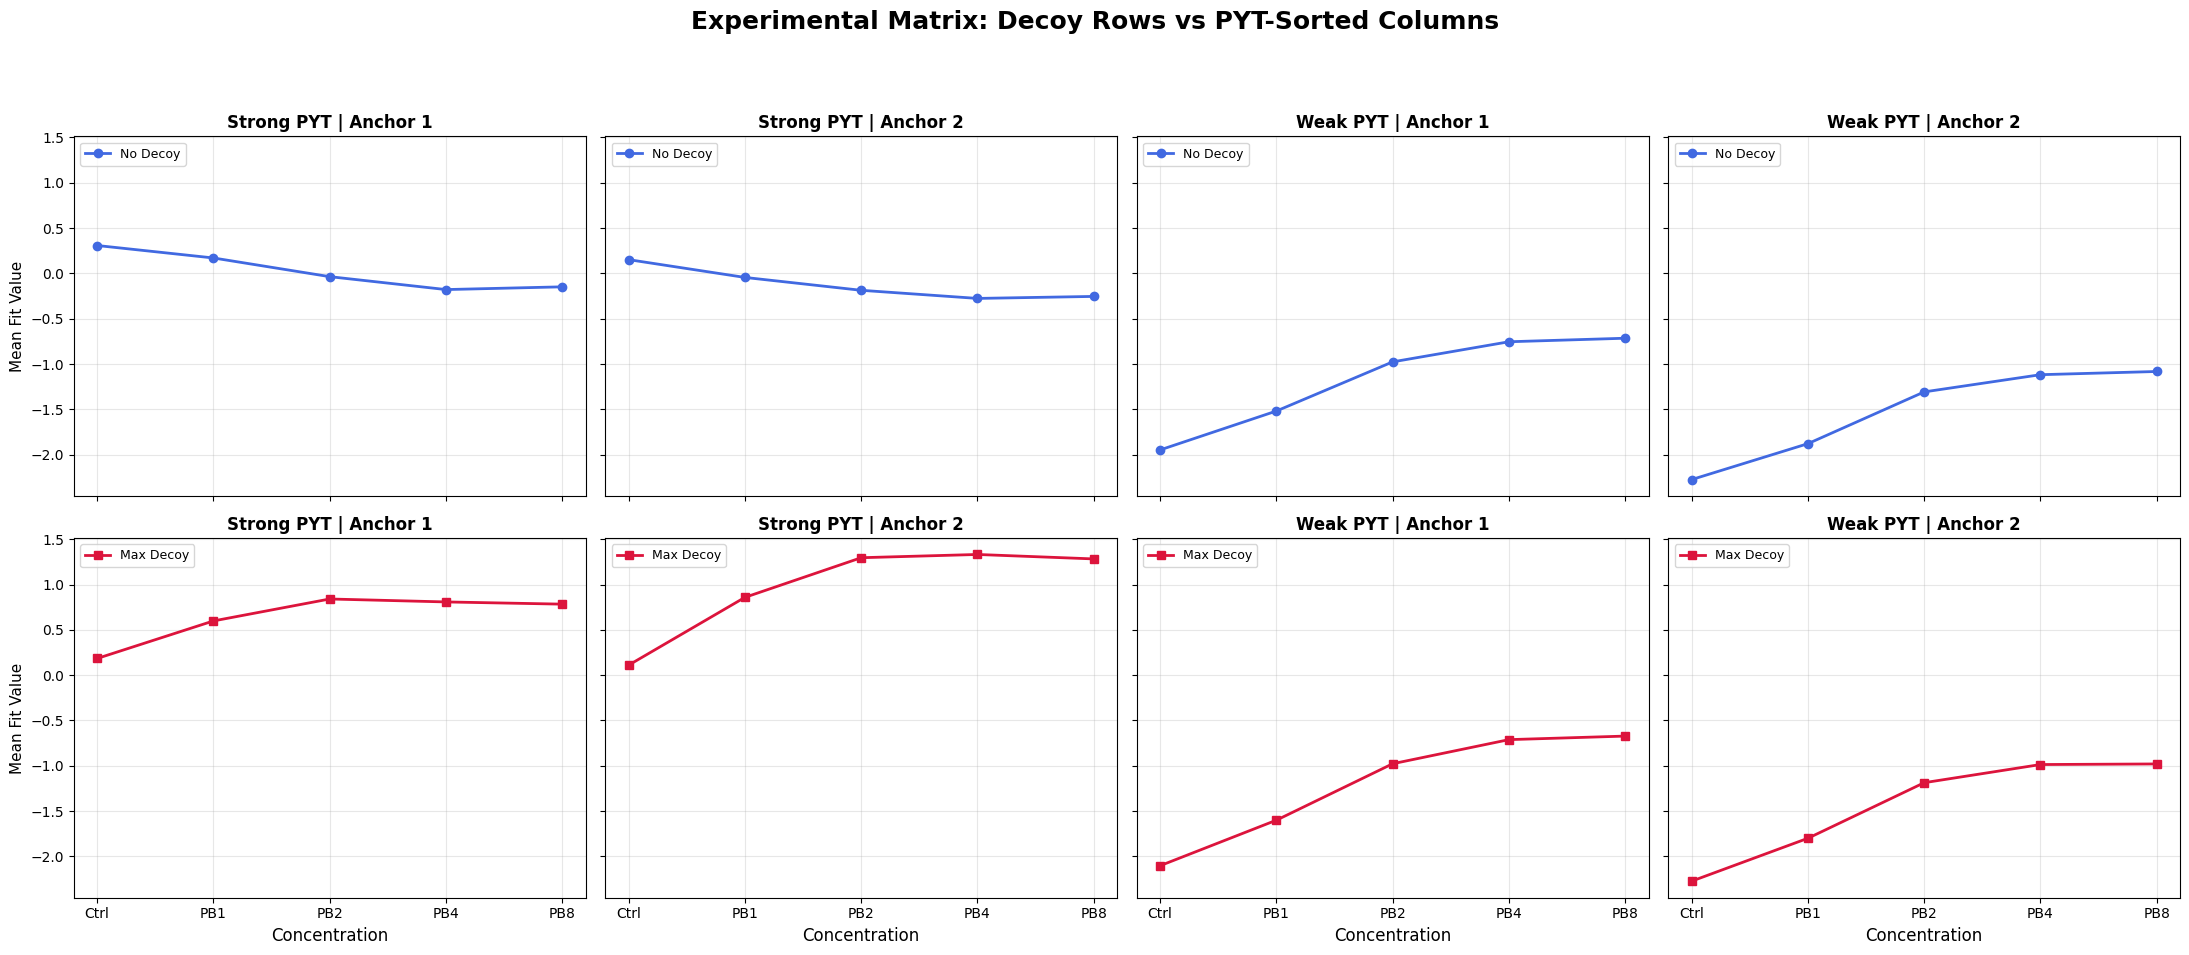

In [4]:
import matplotlib.pyplot as plt

df = data_filtered.copy()

def get_trend_data(df):
    pb_cols = [col for col in df.columns if 'PB' in col and 'fit' in col]
    target_columns = ['fit_Ctrl'] + sorted(pb_cols)
    
    # Calculate means and extract labels
    mean_values = df[target_columns].mean()
    x_labels = [col.split('_')[-1] for col in target_columns]
    return x_labels, mean_values

# Ordered lists to explicitly control column distribution
pyt_types = ['Strong', 'Weak']
anchors = [1, 2]
filter_cols = ['ANCHOR', 'DECOY', 'PYT', 'fit_Ctrl', 'fit_PB1', 'fit_PB2', 'fit_PB4', 'fit_PB8']

# Setup the 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
fig.suptitle('Experimental Matrix: Decoy Rows vs PYT-Sorted Columns', fontsize=18, fontweight='bold')

# Loop through Decoy targets for rows
for row_idx, decoy_target in enumerate(['Decoy 7', 'Decoy 1']):
    col_idx = 0
    
    # Nested loops ordered by PYT first, then ANCHOR to match your requested layout
    for pyt_val in pyt_types:
        for anchor_val in anchors:
            
            ax = axes[row_idx, col_idx]
            
            # Filter the main dataframe for this specific grid cell
            df_sub = data_filtered[filter_cols].copy()
            df_sub = df_sub[
                (df_sub['ANCHOR'] == anchor_val) & 
                (df_sub['PYT'] == pyt_val) & 
                (df_sub['DECOY'] == decoy_target)
            ]
            
            # Visual configuration based on the row condition
            if decoy_target == 'Decoy 7':
                plot_color = 'royalblue'
                plot_marker = 'o'
                decoy_label = 'No Decoy'
            else:
                plot_color = 'crimson'
                plot_marker = 's'
                decoy_label = 'Max Decoy'
                
            # Plot data if the subset contains records
            if not df_sub.empty:
                x, y = get_trend_data(df_sub)
                ax.plot(x, y, marker=plot_marker, color=plot_color, linewidth=2, label=f'{decoy_label}')
                ax.grid(True, alpha=0.3)
                ax.legend(loc='upper left', fontsize=9)
            
            # Subplot title focusing clearly on PYT and ANCHOR
            ax.set_title(f'{pyt_val} PYT | Anchor {anchor_val}', fontsize=12, fontweight='semibold')
            
            # Add Y-axis label only to the first column to keep it clean
            if col_idx == 0:
                ax.set_ylabel('Mean Fit Value', fontsize=11)
                
            col_idx += 1

# Add X-axis label only to the bottom row subplots
for ax in axes[-1, :]:
    ax.set_xlabel('Concentration', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

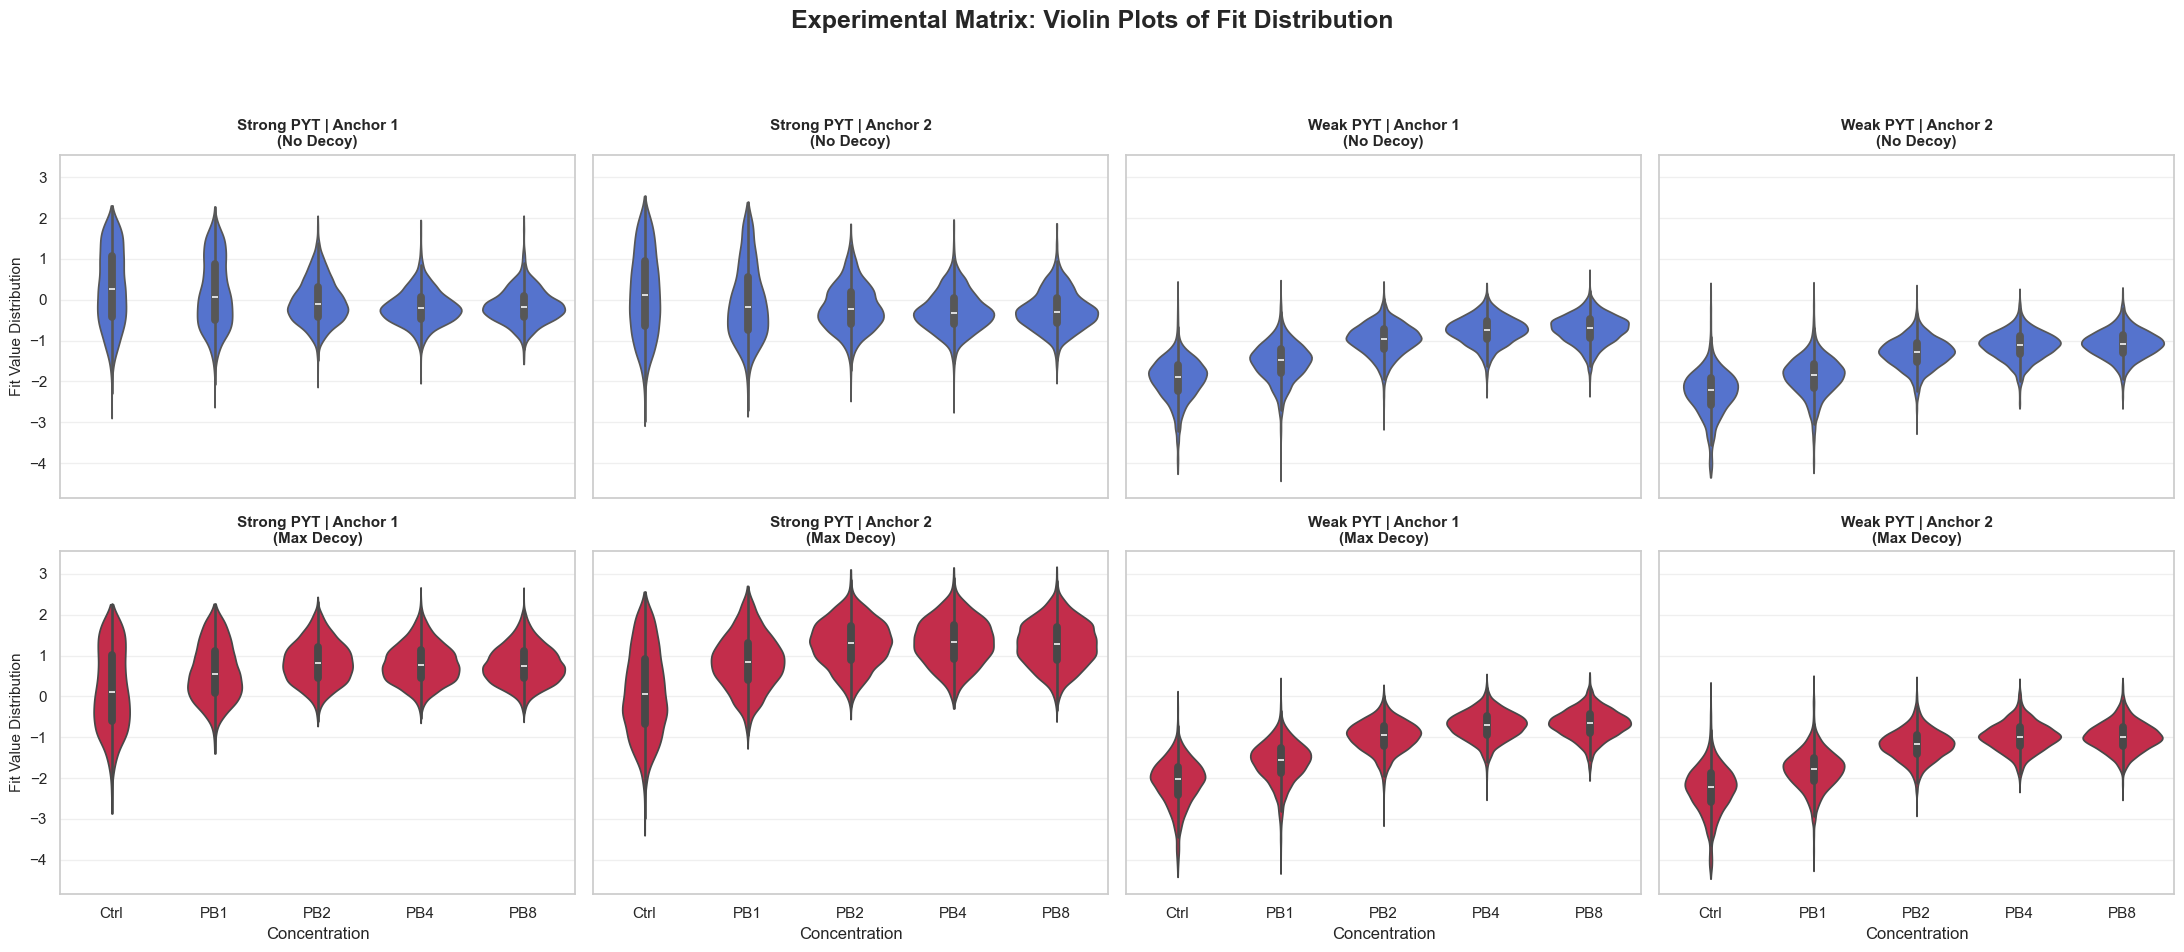

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns  # <--- IMPORTANTE: Aggiungi questa libreria

df = data_filtered.copy()

# Modifichiamo la funzione per estrarre i dati in formato "long" adatto a Seaborn
def get_violin_data(df_sub):
    pb_cols = [col for col in df_sub.columns if 'PB' in col and 'fit' in col]
    target_columns = ['fit_Ctrl'] + sorted(pb_cols)
    
    # Seleziona solo le colonne dei fit e trasforma il dataframe da largo a lungo (melt)
    df_long = df_sub[target_columns].melt(var_name='Condition', value_name='Fit_Value')
    
    # Pulisci i nomi delle etichette (es. 'fit_Ctrl' -> 'Ctrl', 'fit_PB1' -> 'PB1')
    df_long['Condition'] = df_long['Condition'].apply(lambda x: x.split('_')[-1])
    return df_long

# Liste ordinate per controllare la distribuzione delle colonne
pyt_types = ['Strong', 'Weak']
anchors = [1, 2]
filter_cols = ['ANCHOR', 'DECOY', 'PYT', 'fit_Ctrl', 'fit_PB1', 'fit_PB2', 'fit_PB4', 'fit_PB8']

# Setup della griglia 2x4 (Rimosso sharey=True per permettere ai violini di adattarsi meglio, ma puoi rimetterlo)
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
fig.suptitle('Experimental Matrix: Violin Plots of Fit Distribution', fontsize=18, fontweight='bold')

# Loop attraverso i target Decoy per le righe
for row_idx, decoy_target in enumerate(['Decoy 7', 'Decoy 1']):
    col_idx = 0
    
    for pyt_val in pyt_types:
        for anchor_val in anchors:
            
            ax = axes[row_idx, col_idx]
            
            # Filtra il dataframe principale per questa specifica cella della griglia
            df_sub = data_filtered[filter_cols].copy()
            df_sub = df_sub[
                (df_sub['ANCHOR'] == anchor_val) & 
                (df_sub['PYT'] == pyt_val) & 
                (df_sub['DECOY'] == decoy_target)
            ]
            
            # Configurazione visiva basata sulla condizione della riga
            if decoy_target == 'Decoy 7':
                plot_color = 'royalblue'
                decoy_label = 'No Decoy'
            else:
                plot_color = 'crimson'
                decoy_label = 'Max Decoy'
                
            # Genera il Violinplot se il subset contiene dati
            if not df_sub.empty:
                df_plot = get_violin_data(df_sub)
                
                # Creazione del violinplot con Seaborn
                sns.violinplot(
                    data=df_plot, 
                    x='Condition', 
                    y='Fit_Value', 
                    ax=ax, 
                    color=plot_color,
                    inner='box',      # Mostra un mini-boxplot dentro il violino (puoi usare anche 'quartile' o 'point')
                    cut=0             # Limita il violino ai valori reali senza farlo estendere nel vuoto
                )
                
                # Aggiungiamo una legenda manuale text-based o fittizia se necessario, 
                # ma il titolo e il colore della riga identificano già bene il Decoy.
                ax.grid(True, alpha=0.3, axis='y') # Griglia solo orizzontale per i violini
            
            # Titolo del subplot
            ax.set_title(f'{pyt_val} PYT | Anchor {anchor_val}\n({decoy_label})', fontsize=11, fontweight='semibold')
            
            # Rimuove le etichette degli assi di default di Seaborn per non intasare il grafico
            ax.set_xlabel('')
            ax.set_ylabel('')
            
            # Aggiunge l'etichetta Y solo alla prima colonna
            if col_idx == 0:
                ax.set_ylabel('Fit Value Distribution', fontsize=11)
                
            col_idx += 1

# Aggiunge l'etichetta X solo ai subplot dell'ultima riga
for ax in axes[-1, :]:
    ax.set_xlabel('Concentration', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


# Fixing PYT: Strong

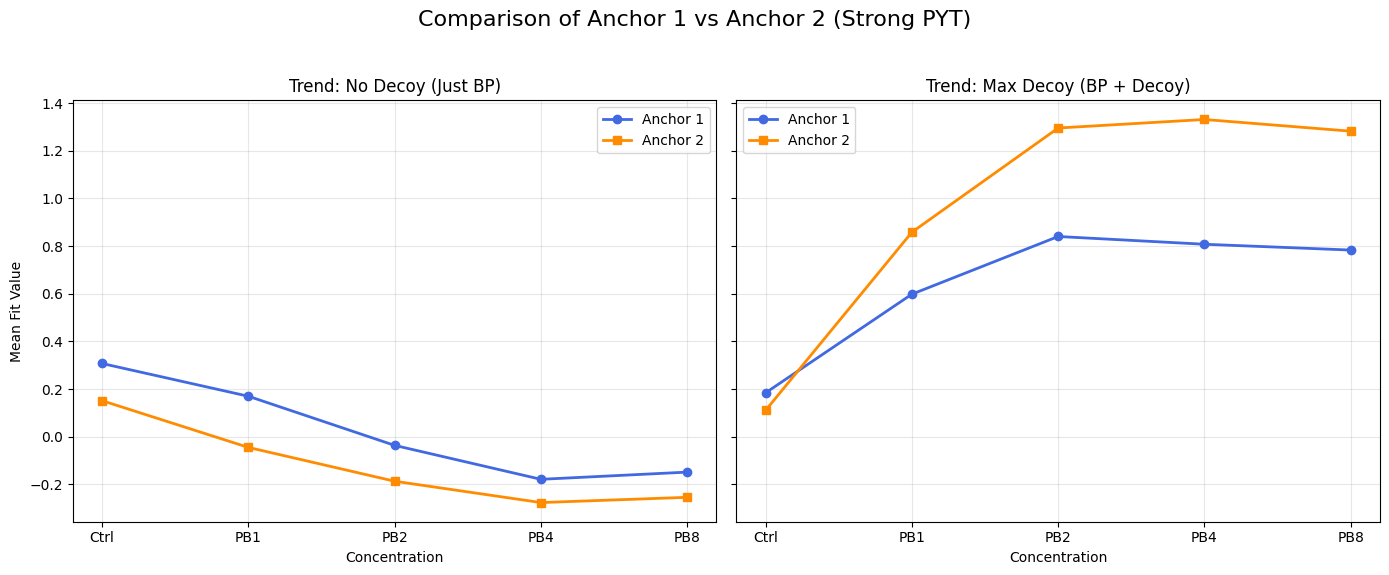

In [5]:

# 1. Define variables and filters
anchors = [1, 2]
pyt_types = ['Strong']
filter_cols = ['ANCHOR', 'DECOY', 'PYT', 'fit_Ctrl', 'fit_PB1', 'fit_PB2', 'fit_PB4', 'fit_PB8']

# 2. Loop through each PYT level (Strong and Weak)
for pyt_val in pyt_types:
    # Create one figure with two subplots for each PYT condition
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(f'Comparison of Anchor 1 vs Anchor 2 ({pyt_val} PYT)', fontsize=16)

    # 3. Loop through anchors to plot them together
    for anchor_val in anchors:
        # Filter the data for the current Anchor and PYT
        df_sub = df[(df['ANCHOR'] == anchor_val) & 
                               (data_filtered['PYT'] == pyt_val)]
        
        # Style settings for Anchor 1 vs Anchor 2
        line_color = 'royalblue' if anchor_val == 1 else 'darkorange'
        marker_type = 'o' if anchor_val == 1 else 's'
        
        # Plot 1: No Decoy (Decoy 7)
        no_decoy = df_sub[df_sub['DECOY'] == 'Decoy 7']
        if not no_decoy.empty:
            x1, y1 = get_trend_data(no_decoy)
            ax1.plot(x1, y1, marker=marker_type, color=line_color, 
                     linewidth=2, label=f'Anchor {anchor_val}')
        
        # Plot 2: Max Decoy (Decoy 1)
        max_decoy = df_sub[df_sub['DECOY'] == 'Decoy 1']
        if not max_decoy.empty:
            x2, y2 = get_trend_data(max_decoy)
            ax2.plot(x2, y2, marker=marker_type, color=line_color, 
                     linewidth=2, label=f'Anchor {anchor_val}')

    # 4. Final formatting for the subplots
    ax1.set_title('Trend: No Decoy (Just BP)')
    ax1.set_ylabel('Mean Fit Value')
    
    ax2.set_title('Trend: Max Decoy (BP + Decoy)')
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Concentration')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Fixing analysis on PYT: Strong, ANCHOR = 1

### Data preparation 

In [6]:
stratified_data = data_filtered[data_filtered['PYT'] == 'Strong']
stratified_data = stratified_data[stratified_data['ANCHOR'] == 1]

no_decoy_stratified = stratified_data[stratified_data['DECOY'] == 'Decoy 7']
max_decoy_stratified = stratified_data[stratified_data['DECOY'] == 'Decoy 1']
# Aggiunta del subset weakest_decoy
weakest_decoy_stratified = stratified_data[stratified_data['DECOY'] == 'Decoy 6']


# We use lambda to pass the specific anchor and pyt strings to the function
max_decoy_stratified['Extracted_BP'] = max_decoy_stratified['full_seq'].apply(
    lambda x: extract_bp(x)
)
no_decoy_stratified['Extracted_BP'] = no_decoy_stratified['full_seq'].apply(
    lambda x: extract_bp(x)
)
# Applicazione della funzione anche al nuovo subset
weakest_decoy_stratified['Extracted_BP'] = weakest_decoy_stratified['full_seq'].apply(
    lambda x: extract_bp(x)
)

print("--- Filtering Result ---")
print(f"The - no_decoy - dataset has now: {no_decoy_stratified.shape[0]} sequences")
print(f"The - max_decoy - dataset has now: {max_decoy_stratified.shape[0]} sequences")
print(f"The - weakest_decoy - dataset has now: {weakest_decoy_stratified.shape[0]} sequences")

--- Filtering Result ---
The - no_decoy - dataset has now: 3737 sequences
The - max_decoy - dataset has now: 3838 sequences
The - weakest_decoy - dataset has now: 3818 sequences


# -----             State Variation Understanding                   ------

To understand the probability occurrance of the states, we can look into the data and extract the expected trends of the model.

- By setting no decoy we can see the trend of the BP-correct site (give that all the other variables are fixed)

- By subsetting the less enriched BP sequences (10th percentile) that are present both in the no_decoy and the decoy we can extract the 'less responsive BP' and so isolate the only effect of the decoy.

## Only BP influence 

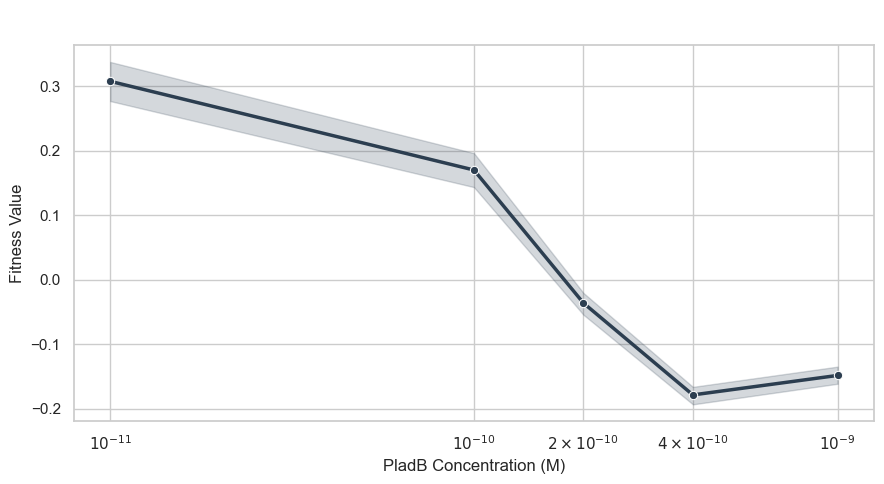

In [7]:
plot_fitness_vs_concentration(no_decoy_stratified, titles = ' ')

## Stronghest Decoy influence 

To look into the decoy influence only we have to reduce the BP's signal. To reduce the BP signal we used 

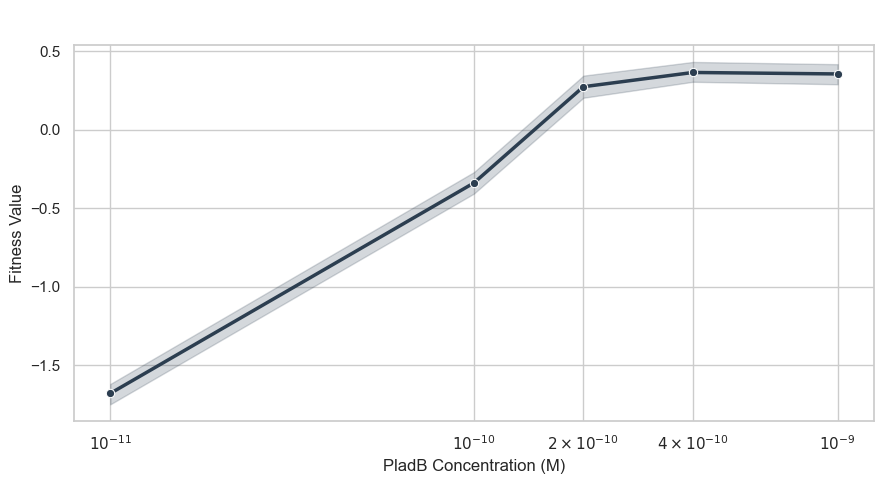

In [8]:
fifth_percentile_dec = max_decoy_stratified['fit_Ctrl'].quantile(0.05)
fifth_percentile_no_dec = no_decoy_stratified['fit_Ctrl'].quantile(0.05)
less_enrich_BP_decoy = max_decoy_stratified[max_decoy_stratified['fit_Ctrl'] < fifth_percentile_dec]
less_enrich_BP_no_decoy = no_decoy_stratified[no_decoy_stratified['fit_Ctrl'] < fifth_percentile_no_dec]

common_bp = set(less_enrich_BP_decoy['Extracted_BP']) & set(less_enrich_BP_no_decoy['Extracted_BP'])

less_enriched_shared = max_decoy_stratified[max_decoy_stratified['Extracted_BP'].isin(common_bp)]


plot_fitness_vs_concentration(less_enriched_shared, titles= ' ')

## Weackest decoy inspection 

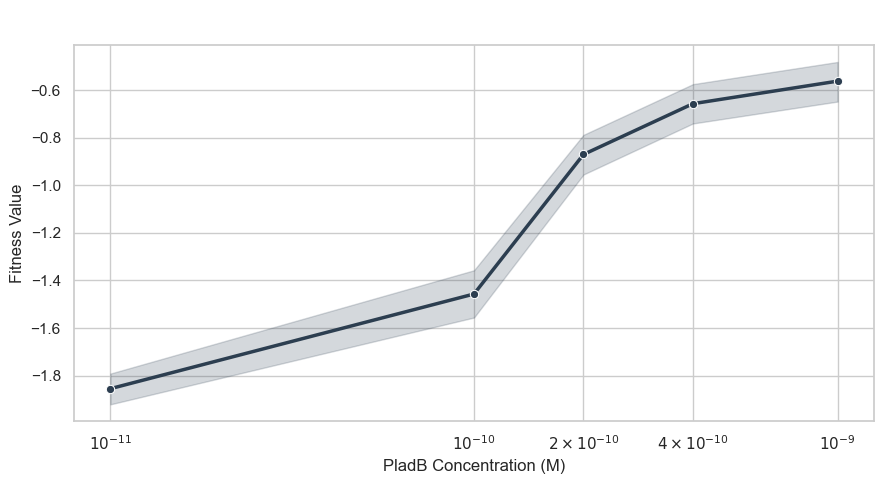

In [9]:
fifth_percentile_dec = weakest_decoy_stratified['fit_Ctrl'].quantile(0.05)
fifth_percentile_no_dec = no_decoy_stratified['fit_Ctrl'].quantile(0.05)
less_enrich_BP_decoy = weakest_decoy_stratified[weakest_decoy_stratified['fit_Ctrl'] < fifth_percentile_dec]
less_enrich_BP_no_decoy = no_decoy_stratified[no_decoy_stratified['fit_Ctrl'] < fifth_percentile_no_dec]

common_bp = set(less_enrich_BP_decoy['Extracted_BP']) & set(less_enrich_BP_no_decoy['Extracted_BP'])

less_enriched_shared = weakest_decoy_stratified[weakest_decoy_stratified['Extracted_BP'].isin(common_bp)]


plot_fitness_vs_concentration(less_enriched_shared, titles= ' ')

# Fitness variation for 1000 sequences

In [10]:
%%capture
# --- PARAMETERS ---
NUM_SEQUENCES = 1000  # You can change this value easily
# ------------------

# 1. Find the common sequences (intersection) between both groups
common_seqs = np.intersect1d(no_decoy_stratified['Extracted_BP'], max_decoy_stratified['Extracted_BP'])
if len(common_seqs) == 0:
    raise ValueError("No overlapping sequences")

# 2. Randomly select the sequences to track


if len(common_seqs) >= NUM_SEQUENCES:
    selected_seqs = np.random.choice(common_seqs, size=NUM_SEQUENCES, replace=False)
else:
    print(f"Warning: Only {len(common_seqs)} common sequences found.")
    selected_seqs = common_seqs

# 3. Filter the dataframes to include only the selected sequences
no_decoy_sample = no_decoy_stratified[no_decoy_stratified['Extracted_BP'].isin(selected_seqs)]
max_decoy_sample = max_decoy_stratified[max_decoy_stratified['Extracted_BP'].isin(selected_seqs)]

# 4. Visualization function
def plot_selected_trends(df, ax, title, line_color):
    pb_cols = [col for col in df.columns if 'PB' in col and 'fit' in col]
    target_columns = ['fit_Ctrl'] + sorted(pb_cols)
    x_labels = [col.split('_')[-1] for col in target_columns]
    
    # Plot each selected sequence
    for seq in selected_seqs:
        # Extract data for this specific sequence
        seq_data = df[df['Extracted_BP'] == seq][target_columns].mean()
        ax.plot(x_labels, seq_data, color=line_color, alpha=0.2, linewidth=1)
    
    # Overlay the Mean of this specific sample
    sample_mean = df[target_columns].mean()
    ax.plot(x_labels, sample_mean, color='black', marker='o', linewidth=3, label='Sample Mean')
    
    ax.set_title(title)
    ax.set_xlabel('Concentration')
    ax.grid(True, alpha=0.2)
    ax.legend()

# 5. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle(f'Tracking the same {len(selected_seqs)} sequences across conditions', fontsize=16)

plot_selected_trends(no_decoy_sample, ax1, 'No Decoy (Selected Seqs)', 'royalblue')
ax1.set_ylabel('Fitness Value')

plot_selected_trends(max_decoy_sample, ax2, 'Max Decoy (Selected Seqs)', 'crimson')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Single sequence tracking

C:\Users\marco\AppData\Local\Temp\ipykernel_1184\3895998104.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\marco\AppData\Local\Temp\ipykernel_1184\3895998104.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


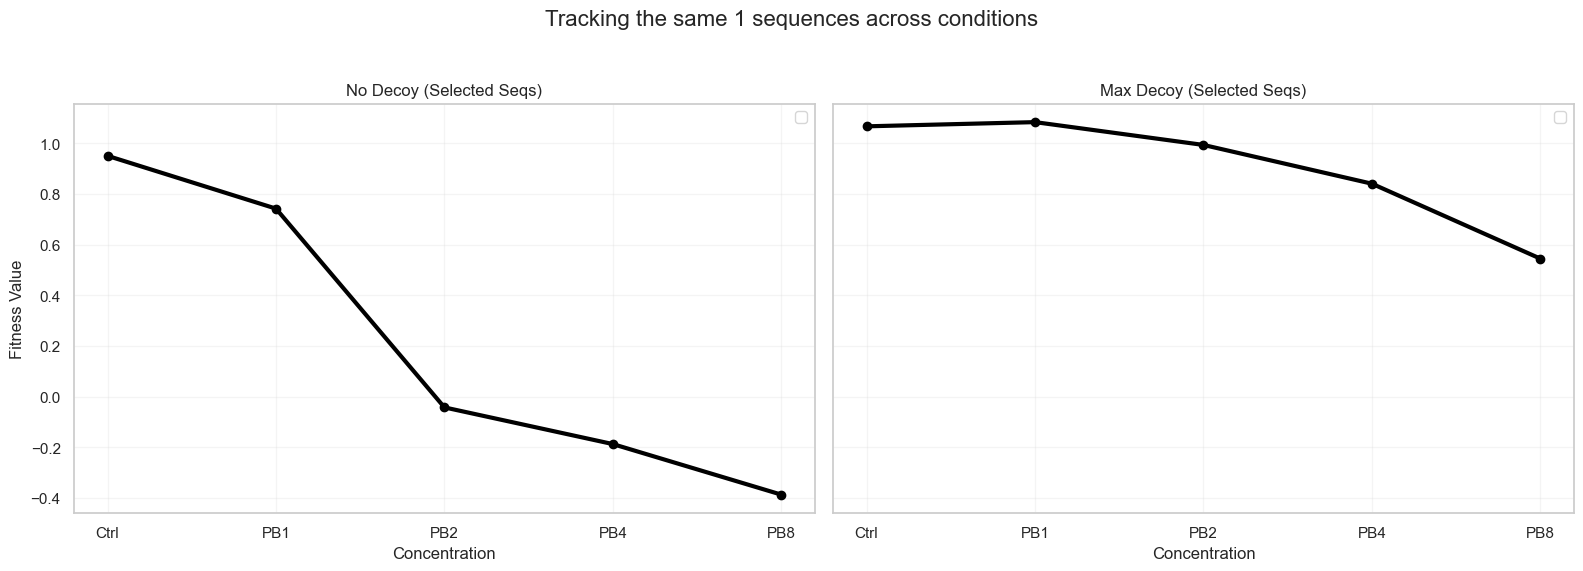

In [11]:
# --- PARAMETERS ---
NUM_SEQUENCES = 1  # You can change this value easily
# ------------------

# 1. Find the common sequences (intersection) between both groups
common_seqs = np.intersect1d(no_decoy_stratified['Extracted_BP'], max_decoy_stratified['Extracted_BP'])
if len(common_seqs) == 0:
    raise ValueError("No overlapping sequences")

# 2. Randomly select the sequences to track


if len(common_seqs) >= NUM_SEQUENCES:
    selected_seqs = np.random.choice(common_seqs, size=NUM_SEQUENCES, replace=False)
else:
    print(f"Warning: Only {len(common_seqs)} common sequences found.")
    selected_seqs = common_seqs

# 3. Filter the dataframes to include only the selected sequences
no_decoy_sample = no_decoy_stratified[no_decoy_stratified['Extracted_BP'].isin(selected_seqs)]
max_decoy_sample = max_decoy_stratified[max_decoy_stratified['Extracted_BP'].isin(selected_seqs)]

# 4. Visualization function
def plot_selected_trends(df, ax, title, line_color):
    pb_cols = [col for col in df.columns if 'PB' in col and 'fit' in col]
    target_columns = ['fit_Ctrl'] + sorted(pb_cols)
    x_labels = [col.split('_')[-1] for col in target_columns]
    
    # Plot each selected sequence
    for seq in selected_seqs:
        # Extract data for this specific sequence
        seq_data = df[df['Extracted_BP'] == seq][target_columns].mean()
        ax.plot(x_labels, seq_data, color=line_color, alpha=0.2, linewidth=1)
    
    # Overlay the Mean of this specific sample
    sample_mean = df[target_columns].mean()
    ax.plot(x_labels, sample_mean, color='black', marker='o', linewidth=3)
    
    ax.set_title(title)
    ax.set_xlabel('Concentration')
    ax.grid(True, alpha=0.2)
    ax.legend()

# 5. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle(f'Tracking the same {len(selected_seqs)} sequences across conditions', fontsize=16)

plot_selected_trends(no_decoy_sample, ax1, 'No Decoy (Selected Seqs)', 'royalblue')
ax1.set_ylabel('Fitness Value')

plot_selected_trends(max_decoy_sample, ax2, 'Max Decoy (Selected Seqs)', 'crimson')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Multiple sites hypothesis


In [12]:
df = data_filtered[data_filtered['PYT'] == 'Strong'].copy()
only_bp = df[(df['DECOY'] == 'Decoy 7') & (df['ANCHOR'] == 1)]
bp_and_anchor_bp = df[(df['DECOY'] == 'Decoy 7') & (df['ANCHOR'] == 2)]
weak_decoy = df[(df['DECOY'] == 'Decoy 6') & (df['ANCHOR'] == 1)]
strong_decoy = df[(df['DECOY'] == 'Decoy 1') & (df['ANCHOR'] == 1)]

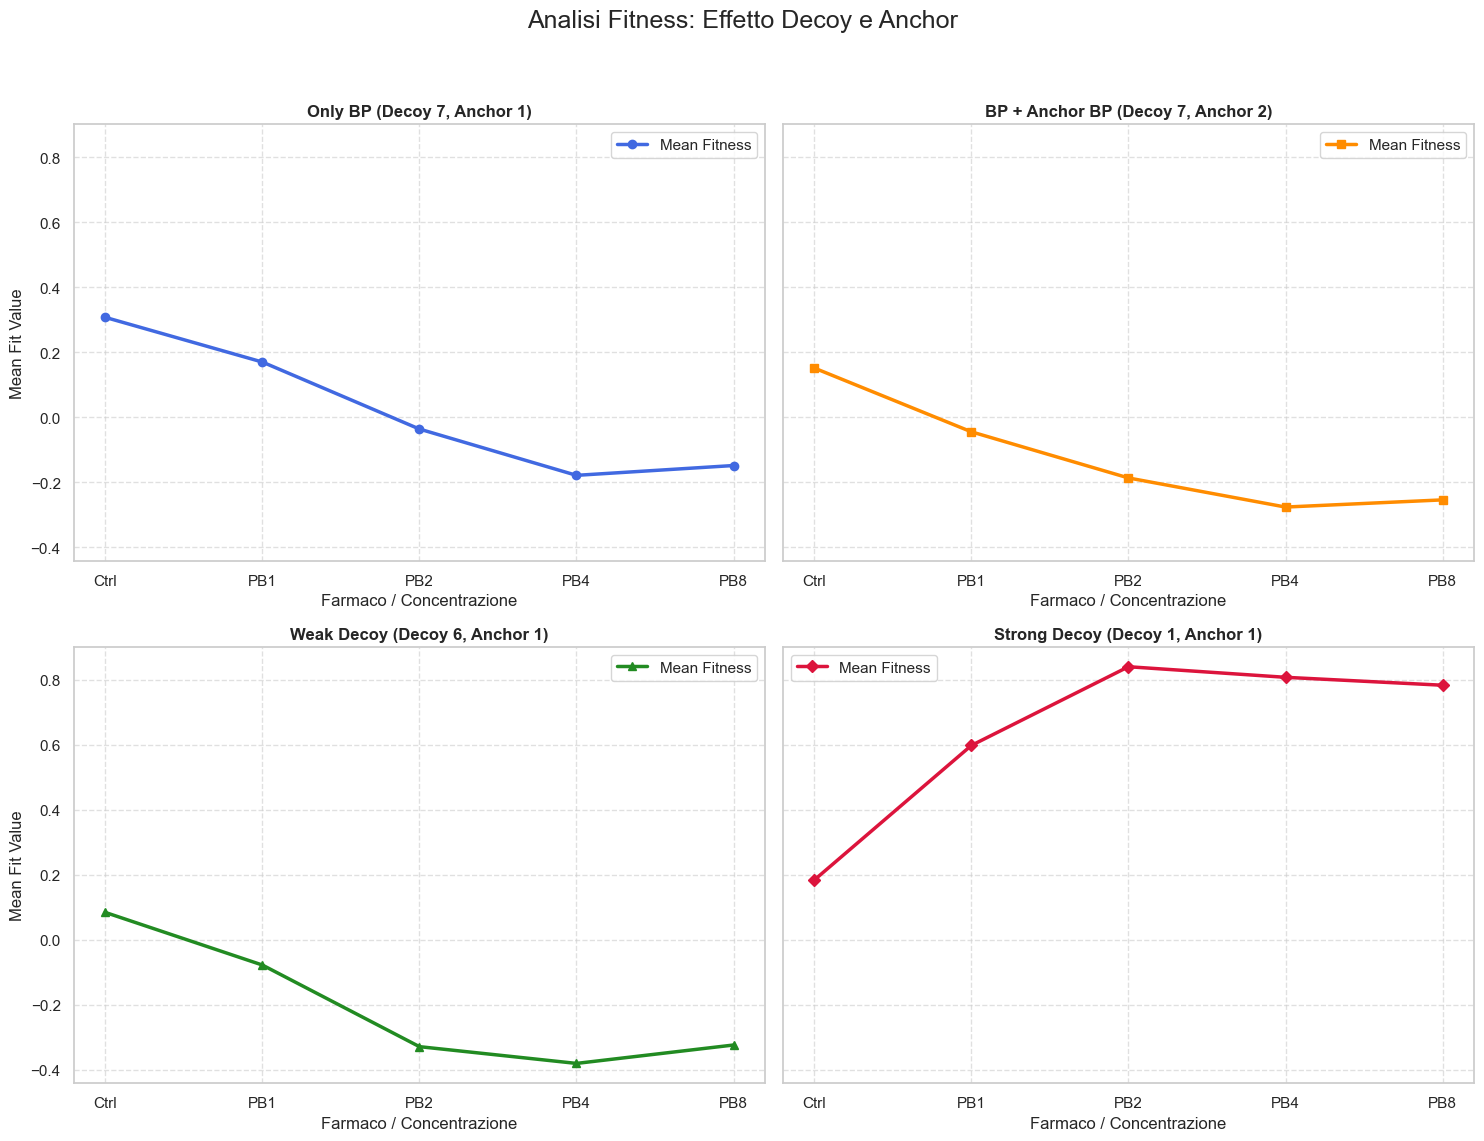

In [13]:
# La tua funzione originale (leggermente ottimizzata per i nomi colonne)
def get_trend_data(df):
    pb_cols = [col for col in df.columns if 'PB' in col and 'fit' in col]
    # Ordiniamo PB1, PB2, PB4, PB8 per evitare linee "incrociate" nel grafico
    target_columns = ['fit_Ctrl'] + sorted(pb_cols, key=lambda x: int(x.split('PB')[-1]) if 'PB' in x else 0)
    
    mean_values = df[target_columns].mean()
    x_labels = [col.split('_')[-1] for col in target_columns]
    return x_labels, mean_values

# 1. Creazione della figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharey=True)
fig.suptitle('Analisi Fitness: Effetto Decoy e Anchor', fontsize=18)

# Mappatura dei dataframe sulla griglia
# (riga, colonna, dataframe, titolo, colore, marker)
scenarios = [
    (0, 0, only_bp, 'Only BP (Decoy 7, Anchor 1)', 'royalblue', 'o'),
    (0, 1, bp_and_anchor_bp, 'BP + Anchor BP (Decoy 7, Anchor 2)', 'darkorange', 's'),
    (1, 0, weak_decoy, 'Weak Decoy (Decoy 6, Anchor 1)', 'forestgreen', '^'),
    (1, 1, strong_decoy, 'Strong Decoy (Decoy 1, Anchor 1)', 'crimson', 'D')
]

# 2. Ciclo di popolamento della griglia
for row, col, df, title, color, marker in scenarios:
    ax = axes[row, col]
    
    if not df.empty:
        x, y = get_trend_data(df)
        ax.plot(x, y, marker=marker, color=color, linewidth=2.5, label='Mean Fitness')
        
        # Estetica del singolo subplot
        ax.set_title(title, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_xlabel('Farmaco / Concentrazione')
        if col == 0: # Etichetta Y solo sui grafici di sinistra per pulizia
            ax.set_ylabel('Mean Fit Value')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Dati non disponibili', ha='center', va='center')

# 3. Ottimizzazione finale
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()